In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/salary-data/Salary Data.csv


## Predicting Employee Salaries using Regression Algorithms in Scikit-learn

**This project predicts employee salaries using machine learning. It cleans the data, explores important features, and builds models like Linear Regression, Decision Tree, Random Forest, and KNN to find the best and most accurate salary prediction model.**

**Loading Dataset**

In [2]:
dataset = pd.read_csv("/kaggle/input/salary-data/Salary Data.csv")

In [3]:
dataset.head(5)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
dataset.shape

(375, 6)

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


## Data Cleaning

**Checking missing value**

In [6]:
dataset.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [7]:
import warnings
warnings.filterwarnings('ignore')

**Handling the missing value**

In [8]:
dataset["Age"].fillna(dataset["Age"].mean(), inplace = True)
dataset["Years of Experience"].fillna(dataset["Years of Experience"].mean(), inplace = True)
dataset["Salary"].fillna(dataset["Salary"].mean(), inplace = True)
dataset["Gender"].fillna(dataset["Gender"].mode()[0], inplace = True)
dataset["Education Level"].fillna(dataset["Education Level"].mode()[0], inplace = True)
dataset["Job Title"].fillna(dataset["Job Title"].mode()[0], inplace = True)

In [9]:
dataset.head(3)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0


In [10]:
dataset.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

**Checking Duplicates Value**

In [11]:
dataset.duplicated().sum()

50

**Removing Duplicated Value**

In [12]:
dataset = dataset.drop_duplicates(keep = "first")

In [13]:
dataset.shape

(325, 6)

## Data Visualization

**Relationship between Experience & Salary**

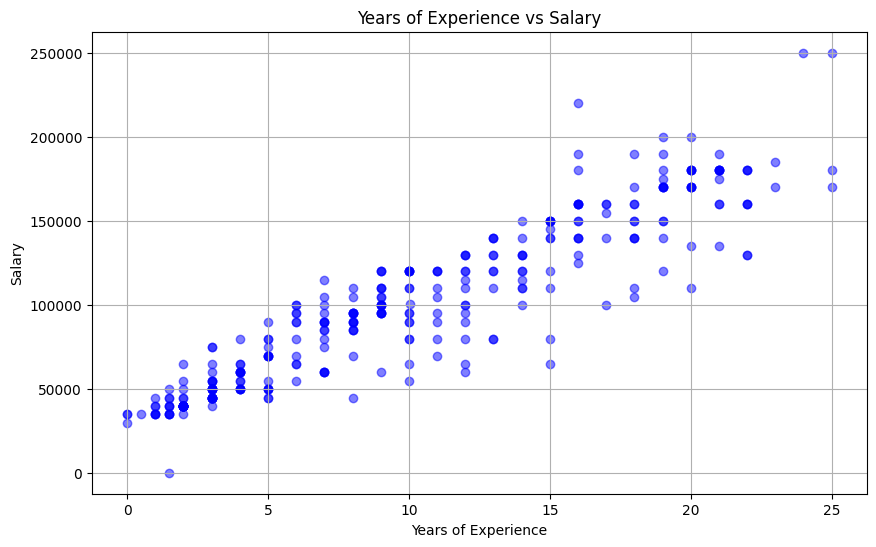

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(dataset["Years of Experience"],dataset["Salary"],alpha =0.5,color = "blue")
plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

## Feature Engineering

In [15]:
dataset.describe()

,Age,Years of Experience,Salary
count,325.000000,325.000000,325.000000
mean,37.382867,10.058556,99987.468756
std,7.174747,6.640199,48577.143840
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,37.000000,9.000000,95000.000000
75%,44.000000,16.000000,140000.000000
max,53.000000,25.000000,250000.000000


**Outlier Removal using IQR**

In [16]:
q1 = dataset["Salary"].quantile(0.25)
q3 = dataset["Salary"].quantile(0.75)
IQR = q3 - q1
min_range = q1 - (1.5*IQR)
max_range = q3 +(1.5*IQR)
salary_dataset = dataset[(dataset["Salary"] >= min_range) & (dataset["Salary"] <= max_range)]

In [17]:
salary_dataset.shape

(325, 6)

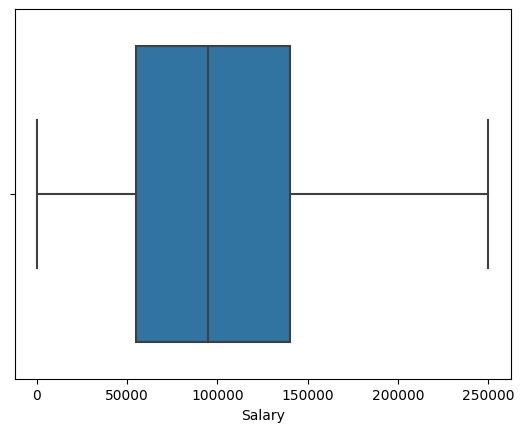

In [18]:
sns.boxplot(x = "Salary", data = salary_dataset)
plt.show()

In [19]:
salary_dataset.nunique()

Age                     32
Gender                   2
Education Level          3
Job Title              174
Years of Experience     29
Salary                  37
dtype: int64

**Encoding Categorical Features**

In [20]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

salary_dataset["Gender"] = encoder.fit_transform(salary_dataset["Gender"])
salary_dataset["Education Level"] = encoder.fit_transform(salary_dataset["Education Level"])
salary_dataset["Job Title"] = encoder.fit_transform(salary_dataset["Job Title"])

In [21]:
salary_dataset.head(4)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0


In [22]:
salary_dataset.describe()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
count,325.000000,325.000000,325.000000,325.000000,325.000000,325.000000
mean,37.382867,0.526154,0.538462,88.772308,10.058556,99987.468756
std,7.174747,0.500085,0.713125,47.151422,6.640199,48577.143840
min,23.000000,0.000000,0.000000,0.000000,0.000000,350.000000
25%,31.000000,0.000000,0.000000,49.000000,4.000000,55000.000000
50%,37.000000,1.000000,0.000000,91.000000,9.000000,95000.000000
75%,44.000000,1.000000,1.000000,132.000000,16.000000,140000.000000
max,53.000000,1.000000,2.000000,173.000000,25.000000,250000.000000


**Correlation Heatmap**

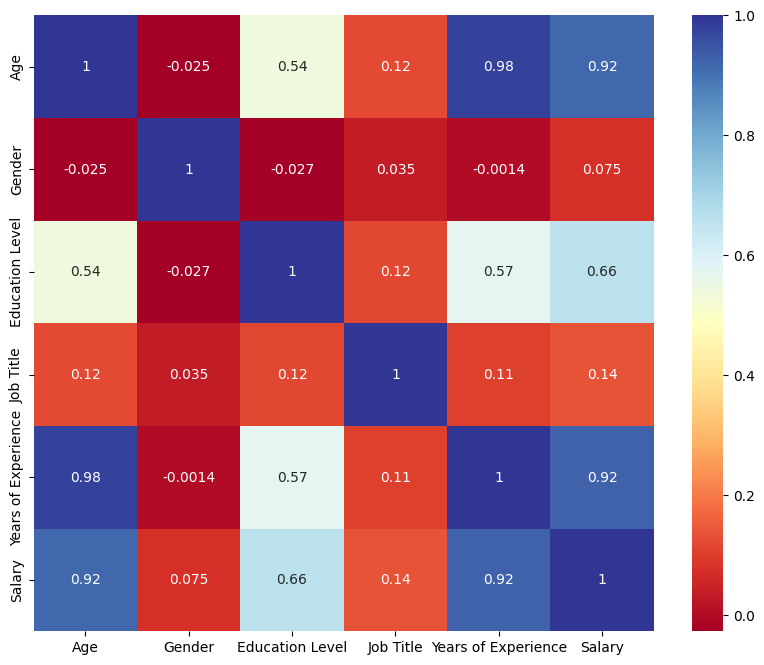

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(data = salary_dataset.corr(),annot=True,cmap="RdYlBu")
plt.show()

## Model Building

**Create Independent & Dependent Variable**

In [24]:
x = salary_dataset.iloc[:,:-1]
y = salary_dataset["Salary"]

In [25]:
from sklearn.preprocessing import MinMaxScaler
min_max = MinMaxScaler()
x = min_max.fit_transform(x)

**Train Test Split**

In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

## Linear Regression

In [27]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred_lr = lr.predict(x_test)

In [28]:
print("Training Score :",lr.score(x_train,y_train))
print("Testing Score :",lr.score(x_test,y_test))

Training Score : 0.8846076140659067
Testing Score : 0.934793672580354


In [29]:
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [30]:
accuracy = cross_val_score(lr,x_train,y_train)

print("Accuracy :{:2f}%".format(accuracy.mean()*100))
print("Standard Deviation :{:2f}%".format(accuracy.std()*100))

Accuracy :87.629427%
Standard Deviation :4.045604%


In [31]:
r2_score_lr = metrics.r2_score(y_test,y_pred_lr)

print("R2 Score: {:2f}%".format(r2_score_lr*100))

R2 Score: 93.479367%


In [32]:
mae = mean_absolute_error(y_test,y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)

Mean Absolute Error : 9300.52220151962
Mean Squared Error : 148857171.26514268


## Decision Tree Regressor

In [33]:
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor(splitter='best',random_state=42,criterion='squared_error')
dtr.fit(x_train,y_train)
y_pred_dtr = dtr.predict(x_test)

In [34]:
print("Training Score :",dtr.score(x_train,y_train))
print("Testing Score :",dtr.score(x_test,y_test))

Training Score : 0.9983765160404252
Testing Score : 0.9174558723470985


In [35]:
accuracy = cross_val_score(dtr,x_train,y_train)

print("Accuracy :{:2f}%".format(accuracy.mean()*100))
print("Standard Deviation :{:2f}%".format(accuracy.std()*100))

Accuracy :83.318282%
Standard Deviation :10.324411%


In [36]:
r2_score_dtr = metrics.r2_score(y_test,y_pred_dtr)

print("R2 Score: {:2f}%".format(r2_score_dtr*100))

R2 Score: 91.745587%


In [37]:
mae = mean_absolute_error(y_test,y_pred_dtr)
mse = mean_squared_error(y_test, y_pred_dtr)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)

Mean Absolute Error : 9728.076923076924
Mean Squared Error : 188437009.6153846


## Random Forest Regressor

In [38]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=100, min_samples_split=2,min_samples_leaf=1,max_depth=20,max_features = "log2",random_state=42)
rfr.fit(x_train,y_train)
y_pred_rfr = rfr.predict(x_test)

In [39]:
print("Training Score :",rfr.score(x_train,y_train)*100)
print("Testing Score :",rfr.score(x_test,y_test)*100)

Training Score : 98.61052656509447
Testing Score : 95.78173517283147


In [40]:
accuracy = cross_val_score(rfr,x_train,y_train)

print("Accuracy :{:2f}%".format(accuracy.mean()*100))
print("Standard Deviation :{:2f}%".format(accuracy.std()*100))

Accuracy :89.242422%
Standard Deviation :5.998490%


In [41]:
r2_score_rfr = metrics.r2_score(y_test,y_pred_rfr)

print("R2 Score: {:2f}%".format(r2_score_rfr*100))

R2 Score: 95.781735%


In [42]:
mae = mean_absolute_error(y_test,y_pred_rfr)
mse = mean_squared_error(y_test, y_pred_rfr)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)

Mean Absolute Error : 7496.909453839279
Mean Squared Error : 96297245.17046899


## KNeighborsRegressor

In [43]:
from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor(n_neighbors=5,weights="distance")
knr.fit(x_train,y_train)
y_pred_knr = knr.predict(x_test)

In [44]:
print("Training Score :",knr.score(x_train,y_train)*100)
print("Testing Score :",knr.score(x_test,y_test)*100)

Training Score : 99.83765160404252
Testing Score : 92.71290189368362


In [45]:
accuracy = cross_val_score(knr,x_train,y_train)

print("Accuracy :{:2f}%".format(accuracy.mean()*100))
print("Standard Deviation :{:2f}%".format(accuracy.std()*100))

Accuracy :87.216847%
Standard Deviation :5.130890%


In [46]:
r2_score_knr = metrics.r2_score(y_test,y_pred_knr)

print("R2 Score: {:2f}%".format(r2_score_knr*100))

R2 Score: 92.712902%


In [47]:
mae = mean_absolute_error(y_test,y_pred_knr)
mse = mean_squared_error(y_test, y_pred_knr)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)

Mean Absolute Error : 9507.767620133498
Mean Squared Error : 166354532.41475046


In [48]:
data = pd.DataFrame({"Models":["Linear Regression","Decision Tree Regressor","Random Forest Regressor","KNeighborsRegressor"],
                    "r2 Score":[r2_score_lr*100,r2_score_dtr*100,r2_score_rfr*100,r2_score_knr*100]})

In [49]:
data

,Models,r2 Score
0,Linear Regression,93.479367
1,Decision Tree Regressor,91.745587
2,Random Forest Regressor,95.781735
3,KNeighborsRegressor,92.712902



After comparing all models, the **Random Forest Regressor** gives the **best performance** with:

**Highest R² Score:** 95.78%

**Lowest MAE:** 7,496

**Lowest MSE:** 96,297,245

This means the model can **predict employee salary with very high accuracy** based on features like Age, Experience, Education, Gender, and Job Title.
